## First Implementation of the TFT with only Macro Variables

### Inspecting & Importing Data

In [1]:
import pytorch_forecasting
import warnings
from tqdm import tqdm
warnings.filterwarnings("ignore")
import pandas as pd
import os
import matplotlib.pyplot as plt
import holidays
# different than original example
import lightning.pytorch as pl
import torch
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer, NaNLabelEncoder
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
# using weights and biases to visualise training
from lightning.pytorch.loggers import WandbLogger
wandb_logger = WandbLogger(project="tft", name="tft-longformat")

/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Combining all Macro Data from different frequencies:

- **Quarterly**: GDP
- **Monthly**: CPI, PAYEMS, INDPRO, UNRATE
- **Business Daily**: EUR, GDP, YEN, SOFR and T10Y2Y
- **Daily**: FFR

In [2]:
current_dir = os.getcwd()
repo_path = os.path.dirname(current_dir)

In [3]:
daily_path = repo_path + '/data/macro-vars-daily.csv'
df_daily = pd.read_csv(daily_path)
df_daily = df_daily.rename(columns = {'Unnamed: 0':'date'})
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily = df_daily.drop(columns=["SOFR", "T10Y2Y", "EUR"]) # remove shorter vars: SOFR, T10Y2Y, EUR
print(df_daily.tail(20))

            date     GBP     YEN   FFR
26197 2026-03-22     NaN     NaN  3.64
26198 2026-03-23  1.3385  158.70  3.64
26199 2026-03-24  1.3383  158.90  3.64
26200 2026-03-25  1.3373  159.20  3.64
26201 2026-03-26  1.3353  159.65  3.64
26202 2026-03-27  1.3293  160.16  3.64
26203 2026-03-28     NaN     NaN  3.64
26204 2026-03-29     NaN     NaN  3.64
26205 2026-03-30  1.3191  159.49  3.64
26206 2026-03-31  1.3184  159.08  3.64
26207 2026-04-01  1.3331  158.63  3.64
26208 2026-04-02  1.3241  159.34  3.64
26209 2026-04-03  1.3202  159.64  3.64
26210 2026-04-04     NaN     NaN  3.64
26211 2026-04-05     NaN     NaN  3.64
26212 2026-04-06     NaN     NaN  3.64
26213 2026-04-07     NaN     NaN  3.64
26214 2026-04-08     NaN     NaN  3.64
26215 2026-04-09     NaN     NaN  3.64
26216 2026-04-10     NaN     NaN   NaN


In [4]:
qrtly_path = repo_path + '/data/macro-vars-quarterly.csv'
df_quartly = pd.read_csv(qrtly_path)
df_quartly = df_quartly.rename(columns = {'Unnamed: 0':'date'})
df_quartly['date'] = pd.to_datetime(df_quartly['date'])
print(df_quartly.tail(10))

          date        GDP
310 2023-07-01  28074.846
311 2023-10-01  28424.722
312 2024-01-01  28708.161
313 2024-04-01  29147.044
314 2024-07-01  29511.664
315 2024-10-01  29825.182
316 2025-01-01  30042.113
317 2025-04-01  30485.729
318 2025-07-01  31098.027
319 2025-10-01  31422.526


In [5]:
# os.getcwd()
monthly_path = repo_path + '/data/macro-vars-monthly.csv'
df_monthly = pd.read_csv(monthly_path)
df_monthly = df_monthly.rename(columns = {'Unnamed: 0':'date'})
# remove columns which are too short 
df_monthly = df_monthly.drop(columns=["PCEPI", "JTSJOL", "UMCSENT"])

df_monthly['date'] = pd.to_datetime(df_monthly['date'])
# print(df_monthly.tail(10))

# merge 
df = pd.merge(df_monthly, df_quartly, on='date', how='left')
df = pd.merge(df_daily, df, on='date', how='left') # TODO: only 2 at a time?
# here you can see gdp has a stronger publication lag than the motnhly vars
# print(df.tail(20)) 


In [6]:
# forward-fill monthly/quarterly vars: repeat last published value until updated
monthly_quarterly_cols = ["CPI", "PAYEMS", "INDPRO", "UNRATE", "GDP"]
df[monthly_quarterly_cols] = df[monthly_quarterly_cols].ffill()
print(f"NAs after ffill:\n{df[monthly_quarterly_cols].isna().sum()}")
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}, {len(df)} rows")

NAs after ffill:
CPI       0
PAYEMS    0
INDPRO    0
UNRATE    0
GDP       0
dtype: int64

Date range: 1954-07-01 00:00:00 to 2026-04-10 00:00:00, 26217 rows


In [7]:
print(df.tail(15))

            date     GBP     YEN   FFR      CPI    PAYEMS    INDPRO  UNRATE  \
26202 2026-03-27  1.3293  160.16  3.64  330.293  158637.0  101.7898     4.3   
26203 2026-03-28     NaN     NaN  3.64  330.293  158637.0  101.7898     4.3   
26204 2026-03-29     NaN     NaN  3.64  330.293  158637.0  101.7898     4.3   
26205 2026-03-30  1.3191  159.49  3.64  330.293  158637.0  101.7898     4.3   
26206 2026-03-31  1.3184  159.08  3.64  330.293  158637.0  101.7898     4.3   
26207 2026-04-01  1.3331  158.63  3.64  330.293  158637.0  101.7898     4.3   
26208 2026-04-02  1.3241  159.34  3.64  330.293  158637.0  101.7898     4.3   
26209 2026-04-03  1.3202  159.64  3.64  330.293  158637.0  101.7898     4.3   
26210 2026-04-04     NaN     NaN  3.64  330.293  158637.0  101.7898     4.3   
26211 2026-04-05     NaN     NaN  3.64  330.293  158637.0  101.7898     4.3   
26212 2026-04-06     NaN     NaN  3.64  330.293  158637.0  101.7898     4.3   
26213 2026-04-07     NaN     NaN  3.64  330.293  158

In [8]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 26217 entries, 0 to 26216
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    26217 non-null  datetime64[us]
 1   GBP     13855 non-null  float64       
 2   YEN     13849 non-null  float64       
 3   FFR     26216 non-null  float64       
 4   CPI     26217 non-null  float64       
 5   PAYEMS  26217 non-null  float64       
 6   INDPRO  26217 non-null  float64       
 7   UNRATE  26217 non-null  float64       
 8   GDP     26217 non-null  float64       
dtypes: datetime64[us](1), float64(8)
memory usage: 1.8 MB
None


array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>], dtype=object)

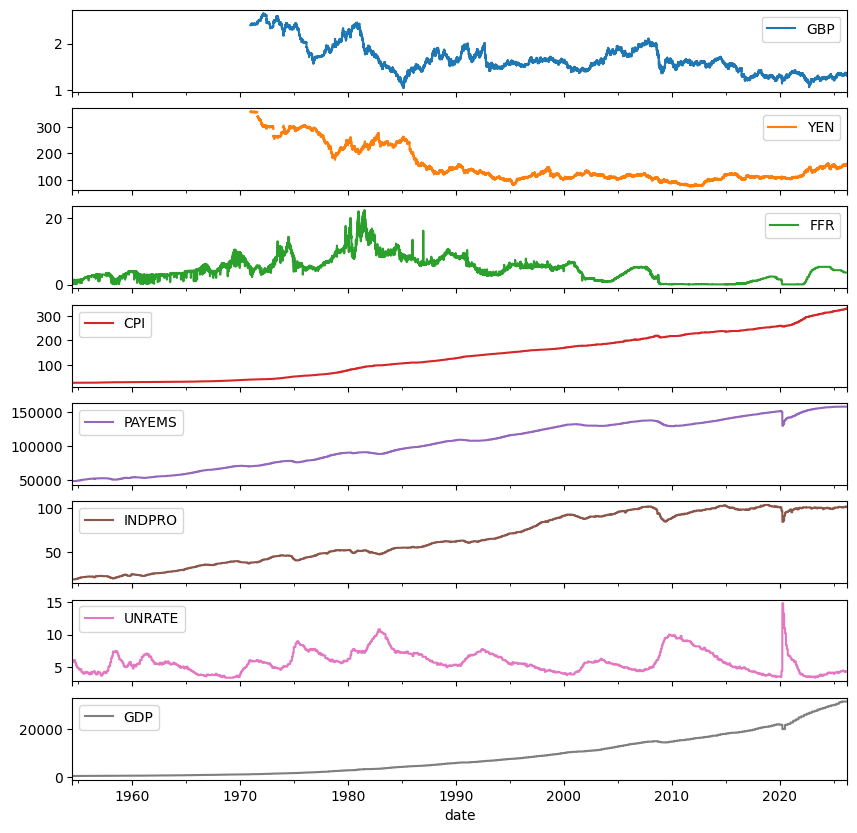

In [9]:
# basic plot to inspect length
df.plot(x='date', y=df.columns.drop("date"), subplots=True, figsize=(10, 10))

#### Meaning of Variables:

**CPI** -> Consumer Price Index 
<!-- **PCEPI** -> Personal Consumption Expenditures Price Index  -->
**PAYEMS** -> Total Nonfarm Payrolls
<!-- **JTSJOL** -> Job Openings: Total Nonfarm (non-farm workers)
**UMCSENT** -> University of Michigan Sentiment Index -->
**INDPRO** -> Industrial Production Index

**UNRATE** -> Unemployment Rate

**GBP** -> Great Britian Pound - USD exchange rate (business daily)
**YEN** -> Janapese Yen - USD exchange rate (business daily)

**FFR** -> Federal Funds Rate, daily

### Implementing TFT

**Info on Model**, based on the following paper: [Temporal Fusion Transformers for Interpretable Multi-horizon Time Series Forecasting](https://arxiv.org/abs/1912.09363)


The TFT should handle single or multiple targets and a whole lot of different covariates such as:

- *static covariates*: these are the ones that do not change through the course of the timeseries. In our case we have country, publication source, etc.  
    - could potentially fetch information from [FRED Website on the different variables](https://fred.stlouisfed.org/series/PAYEMS) for more static covariates? 

- *time series covariates*, they actually belong to 2 different groups:

    - known in advance: such as day_of_the_week, month, holidays, etc.

    - unknown in advance: f.i. if we hade the stock level for each product, we would know it just in the past



In [10]:
# adding time varying known covariates
us_holidays = holidays.US()

df['day_of_week'] = df['date'].dt.dayofweek
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['month'] = df['date'].dt.month
df['is_holiday'] = df['date'].dt.date.apply(lambda d: int(d in us_holidays))

df['series_id'] = 'macro'

# precompute monthly lags: lag=N means the value from N calendar months ago
# use merge_asof so the offset is in months, not rows (which would be meaningless on ffilled daily data)
lag_vars = ["CPI", "PAYEMS", "INDPRO", "UNRATE", "GDP"]
lag_periods = [1, 2, 6, 12] # lag not the actual day but the quarter/month -> else the lag_1 is 1 day for monthly & quarterly vars

source = df[['date'] + lag_vars].sort_values('date').reset_index(drop=True)
for col in lag_vars:
    for lag in lag_periods:
        lookup = pd.DataFrame({
            'date': df['date'] - pd.DateOffset(months=lag),
            '_orig': range(len(df))
        }).sort_values('date').reset_index(drop=True)
        merged = pd.merge_asof(lookup, source[['date', col]], on='date', direction='backward')
        df[f"{col}_lag_{lag}"] = merged.sort_values('_orig')[col].values

# TODO: maybe don't go up to lag 12... then discard a lot of data
# drop rows where 12-month lag is undefined (first ~12 months of series)
df = df.dropna().reset_index(drop=True)

# create time_idx
df = (df.merge((df[['date']].drop_duplicates(ignore_index=True)
.rename_axis('time_idx')).reset_index(), on=['date']))

print(df.tail(10))
print(f"\nRemaining NAs:\n{df.isna().sum()[df.isna().sum() > 0]}")

            date     GBP     YEN   FFR      CPI    PAYEMS    INDPRO  UNRATE  \
13839 2026-03-23  1.3385  158.70  3.64  330.293  158637.0  101.7898     4.3   
13840 2026-03-24  1.3383  158.90  3.64  330.293  158637.0  101.7898     4.3   
13841 2026-03-25  1.3373  159.20  3.64  330.293  158637.0  101.7898     4.3   
13842 2026-03-26  1.3353  159.65  3.64  330.293  158637.0  101.7898     4.3   
13843 2026-03-27  1.3293  160.16  3.64  330.293  158637.0  101.7898     4.3   
13844 2026-03-30  1.3191  159.49  3.64  330.293  158637.0  101.7898     4.3   
13845 2026-03-31  1.3184  159.08  3.64  330.293  158637.0  101.7898     4.3   
13846 2026-04-01  1.3331  158.63  3.64  330.293  158637.0  101.7898     4.3   
13847 2026-04-02  1.3241  159.34  3.64  330.293  158637.0  101.7898     4.3   
13848 2026-04-03  1.3202  159.64  3.64  330.293  158637.0  101.7898     4.3   

             GDP  day_of_week  ...  INDPRO_lag_12  UNRATE_lag_1  UNRATE_lag_2  \
13839  31422.526            0  ...       101.0404

In [11]:
# split into test, train
tr_len = round(len(df) * 0.8)

train = df.iloc[:tr_len]
test = df.iloc[tr_len:]
print(train.tail()) # goes until 2004

            date     GBP     YEN   FFR      CPI    PAYEMS    INDPRO  UNRATE  \
11074 2015-02-26  1.5424  119.36  0.11  235.342  140827.0  102.2335     5.5   
11075 2015-02-27  1.5439  119.72  0.06  235.342  140827.0  102.2335     5.5   
11076 2015-03-02  1.5371  120.06  0.12  235.976  140923.0  101.8914     5.4   
11077 2015-03-03  1.5391  119.47  0.12  235.976  140923.0  101.8914     5.4   
11078 2015-03-04  1.5266  119.76  0.11  235.976  140923.0  101.8914     5.4   

             GDP  day_of_week  ...  INDPRO_lag_12  UNRATE_lag_1  UNRATE_lag_2  \
11074  18063.529            3  ...       100.9168           5.7           5.6   
11075  18063.529            4  ...       100.9168           5.7           5.6   
11076  18063.529            0  ...       101.8942           5.5           5.7   
11077  18063.529            1  ...       101.8942           5.5           5.7   
11078  18063.529            2  ...       101.8942           5.5           5.7   

      UNRATE_lag_6  UNRATE_lag_12  GDP

In [12]:
print(train.columns)

Index(['date', 'GBP', 'YEN', 'FFR', 'CPI', 'PAYEMS', 'INDPRO', 'UNRATE', 'GDP',
       'day_of_week', 'week_of_year', 'month', 'is_holiday', 'series_id',
       'CPI_lag_1', 'CPI_lag_2', 'CPI_lag_6', 'CPI_lag_12', 'PAYEMS_lag_1',
       'PAYEMS_lag_2', 'PAYEMS_lag_6', 'PAYEMS_lag_12', 'INDPRO_lag_1',
       'INDPRO_lag_2', 'INDPRO_lag_6', 'INDPRO_lag_12', 'UNRATE_lag_1',
       'UNRATE_lag_2', 'UNRATE_lag_6', 'UNRATE_lag_12', 'GDP_lag_1',
       'GDP_lag_2', 'GDP_lag_6', 'GDP_lag_12', 'time_idx'],
      dtype='str')


In [13]:
meta_path = repo_path + '/data/metadata-macro.csv'
meta_raw = pd.read_csv(meta_path, index_col=1)
meta_raw = meta_raw.rename(index={'CPIAUCSL': 'CPI', "DEXUSUK": "GBP", "DEXJPUS":"YEN", "DFF":"FFR"})

# years of history through end of training — avoids 0 for GBP/YEN whose series start coincides with train_start
train_end = train['date'].max()
meta_raw['meta_years_of_history'] = meta_raw['observation_start'].apply(
    lambda s: max(0.0, (train_end - pd.to_datetime(s)).days / 365.25)
)
# TODO: include metadata for all vars, not just target??
# add frequency too, now that we have quarterly (and differentiate between 7day daily, and Daily 5 days)
meta = meta_raw[['popularity', 'units_short', 'meta_years_of_history', 'frequency_short']].rename(
    columns={'popularity': 'meta_popularity', 'units_short': 'meta_units', 'frequency_short':'meta_frequency'}
).loc[["CPI", "PAYEMS", "INDPRO", "UNRATE", "GDP"]]

print(meta)

        meta_popularity           meta_units  meta_years_of_history  \
id                                                                    
CPI                 100  Index 1982-1984=100              68.169747   
PAYEMS               86    Thous. of Persons              76.169747   
INDPRO               83       Index 2017=100              96.169747   
UNRATE               98                    %              67.170431   
GDP                  94            Bil. of $              68.169747   

       meta_frequency  
id                     
CPI                 M  
PAYEMS              M  
INDPRO              M  
UNRATE              M  
GDP                 Q  


In [14]:
# adjust to match daily length
max_encoder_length = 48*30  # 4 years lookback
max_prediction_length = 12*30  # 12 months forecast

lag_vars = ["CPI", "PAYEMS", "INDPRO", "UNRATE", "GDP"]
lag_periods = [1, 2, 6, 12]
lagged_cols = [f"{col}_lag_{lag}" for col in lag_vars for lag in lag_periods]

# only include target metadata, other one was too bad.
train_aug = train.assign(**meta.loc["INDPRO"].to_dict())

training = TimeSeriesDataSet(
    data=train_aug,
    time_idx="time_idx",
    target="INDPRO",
    group_ids=["series_id"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["series_id", "meta_units", "meta_frequency"],
    static_reals=["meta_popularity", "meta_years_of_history"],
    time_varying_known_reals=["time_idx", "day_of_week", "week_of_year", "month", "is_holiday"],
    time_varying_known_categoricals=[],
    time_varying_unknown_reals=["CPI", "PAYEMS", "INDPRO", "UNRATE", "GDP"] + lagged_cols,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(training, train_aug, predict=True, stop_randomization=True)

batch_size = 128
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=0)

print(train_aug.columns)
print(train_aug['meta_units'])

Index(['date', 'GBP', 'YEN', 'FFR', 'CPI', 'PAYEMS', 'INDPRO', 'UNRATE', 'GDP',
       'day_of_week', 'week_of_year', 'month', 'is_holiday', 'series_id',
       'CPI_lag_1', 'CPI_lag_2', 'CPI_lag_6', 'CPI_lag_12', 'PAYEMS_lag_1',
       'PAYEMS_lag_2', 'PAYEMS_lag_6', 'PAYEMS_lag_12', 'INDPRO_lag_1',
       'INDPRO_lag_2', 'INDPRO_lag_6', 'INDPRO_lag_12', 'UNRATE_lag_1',
       'UNRATE_lag_2', 'UNRATE_lag_6', 'UNRATE_lag_12', 'GDP_lag_1',
       'GDP_lag_2', 'GDP_lag_6', 'GDP_lag_12', 'time_idx', 'meta_popularity',
       'meta_units', 'meta_years_of_history', 'meta_frequency'],
      dtype='str')
0        Index 2017=100
1        Index 2017=100
2        Index 2017=100
3        Index 2017=100
4        Index 2017=100
              ...      
11074    Index 2017=100
11075    Index 2017=100
11076    Index 2017=100
11077    Index 2017=100
11078    Index 2017=100
Name: meta_units, Length: 11079, dtype: str


In [15]:
print(train_aug.columns)

Index(['date', 'GBP', 'YEN', 'FFR', 'CPI', 'PAYEMS', 'INDPRO', 'UNRATE', 'GDP',
       'day_of_week', 'week_of_year', 'month', 'is_holiday', 'series_id',
       'CPI_lag_1', 'CPI_lag_2', 'CPI_lag_6', 'CPI_lag_12', 'PAYEMS_lag_1',
       'PAYEMS_lag_2', 'PAYEMS_lag_6', 'PAYEMS_lag_12', 'INDPRO_lag_1',
       'INDPRO_lag_2', 'INDPRO_lag_6', 'INDPRO_lag_12', 'UNRATE_lag_1',
       'UNRATE_lag_2', 'UNRATE_lag_6', 'UNRATE_lag_12', 'GDP_lag_1',
       'GDP_lag_2', 'GDP_lag_6', 'GDP_lag_12', 'time_idx', 'meta_popularity',
       'meta_units', 'meta_years_of_history', 'meta_frequency'],
      dtype='str')


### Training and Evaluating TFT for just one variable

this is really just to demonstrate how the tft works, and to explain the decisions i'm making. later, i will loop through all 4 macro variables of interest, and then we will see how they compare to the naive model too.

In [16]:
# setting hyperparams
PATIENCE = 5
MAX_EPOCHS = 40
LEARNING_RATE = 0.03
OPTUNA = False # hyperparam opt

In [17]:
from lightning.pytorch.callbacks.progress import TQDMProgressBar

early_stop_callback = EarlyStopping(monitor="train_loss", min_delta=1e-2, patience=PATIENCE, verbose=False, mode="min")
lr_logger = LearningRateMonitor()  # log the learning rate

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",  # uses MPS on Apple Silicon, CPU otherwise
    devices=1,
    enable_model_summary=True,
    gradient_clip_val=0.25,
    limit_train_batches=5,
    callbacks=[lr_logger, early_stop_callback, TQDMProgressBar(refresh_rate=1)],
    logger=wandb_logger
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=LEARNING_RATE,
    lstm_layers=2,
    hidden_size=16,
    attention_head_size=2,
    dropout=0.2,
    hidden_continuous_size=8,
    output_size=1,  # 7 quantiles by default
    loss=SMAPE(),
    log_interval=10,
    reduce_on_plateau_patience=4
)

tft.to(DEVICE)
print(f"Number of parameters in network: {tft.size()/1e3:.1f}k")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Number of parameters in network: 47.3k


In [18]:
# add tqdm for progress report
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA A100 80GB PCIe MIG 2g.20gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: 

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ SMAPE                           │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      3 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    576 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  3.4 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 22.1 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.7 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  4.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  4.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     17 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 47.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 47.3 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 796                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 10: 100%|██████████| 5/5 [00:47<00:00,  0.10it/s, v_num=cli8, train_loss_step=0.0359, val_loss=0.0588, train_loss_epoch=0.0383]


In [19]:
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])
predictions = best_tft.predict(val_dataloader, mode="prediction")
# print(predictions[:10])
# print(predictions.shape)

raw_output = best_tft.predict(val_dataloader, mode="raw", return_x=True)
# this is how to unpack it 
raw_predictions = raw_output.output
x = raw_output.x

sm = SMAPE()
print(f"Validation median SMAPE loss: {sm.loss(actuals, predictions).mean(axis=1).median().item()}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
I0000 00:00:1777500474.394326    1920 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777500479.318110    1920 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cud

Validation median SMAPE loss: 0.05878451094031334


### Fit Naive and TFT model for all variables of interest
for reference these variables are: "CPI", "PAYEMS", "INDPRO", "UNRATE", "GDP"

In [20]:
# === 1. Reshape to long format: one row per (date, series) ===
rows = []
for var in lag_vars:
    subset = df.drop(columns=['series_id']).copy()
    # series_id is now the variable, not macro
    subset['series_id'] = var
    subset['value'] = subset[var]
    rows.append(subset)

df_long = pd.concat(rows, ignore_index=True).sort_values(['series_id', 'time_idx']).reset_index(drop=True)
for col in meta.columns:
    df_long[col] = df_long['series_id'].map(meta[col])

train_long = df_long[df_long['date'] <= train['date'].max()].reset_index(drop=True)
test_long  = df_long[df_long['date'] > train['date'].max()].reset_index(drop=True)
print(f"Long format: {len(df_long)} rows across {df_long['series_id'].nunique()} series")
print(f"Train: {len(train_long)} | Test: {len(test_long)}")

# print(train_long)

# === 2. Multi-series TimeSeriesDataSet ===
ds_ms = TimeSeriesDataSet(
    data=train_long,
    time_idx='time_idx',
    target='value',
    group_ids=['series_id'],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=['series_id', 'meta_units'],
    static_reals=['meta_popularity', 'meta_years_of_history'],
    time_varying_known_reals=['time_idx', 'day_of_week', 'week_of_year', 'month', 'is_holiday'],
    time_varying_known_categoricals=[],
    time_varying_unknown_reals=lagged_cols,
    # normalises macro vars
    target_normalizer=GroupNormalizer(groups=['series_id'], transformation='softplus'),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

val_ds_ms   = TimeSeriesDataSet.from_dataset(ds_ms, train_long, predict=True, stop_randomization=True)
train_dl_ms = ds_ms.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dl_ms   = val_ds_ms.to_dataloader(train=False, batch_size=batch_size * 10, num_workers=0)

# === 3. Train one model for all series ===
ms_tft = TemporalFusionTransformer.from_dataset(
    ds_ms,
    learning_rate=LEARNING_RATE,
    lstm_layers=2,
    hidden_size=16,
    attention_head_size=2,
    dropout=0.2,
    hidden_continuous_size=8,
    output_size=1,
    loss=SMAPE(),
    log_interval=10,
    reduce_on_plateau_patience=4,
)

t_ms = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='auto',
    devices=1,
    gradient_clip_val=0.25,
    limit_train_batches=5,
    callbacks=[
        EarlyStopping(monitor='train_loss', min_delta=1e-2, patience=PATIENCE, verbose=False, mode='min'),
        LearningRateMonitor(),
        TQDMProgressBar(refresh_rate=2),
    ],
    enable_model_summary=True,
    logger=wandb_logger
)
t_ms.fit(ms_tft, train_dataloaders=train_dl_ms, val_dataloaders=val_dl_ms)
best_ms_tft = TemporalFusionTransformer.load_from_checkpoint(t_ms.checkpoint_callback.best_model_path)

# print(train_long)

Long format: 69245 rows across 5 series
Train: 55395 | Test: 13850


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ SMAPE                           │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     40 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    496 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  3.3 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 18.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.7 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  4.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  4.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     17 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 43.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 43.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 716                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 13: 100%|██████████| 5/5 [00:43<00:00,  0.11it/s, v_num=cli8, train_loss_step=0.0722, val_loss=0.0928, train_loss_epoch=0.0789]


In [25]:
sm = SMAPE()

# predictions + index for per-series filtering (val_dl_ms is deterministic, order is stable)
ms_preds,x, ms_idx, dec, y = best_ms_tft.predict(val_dl_ms, mode='prediction', return_index=True)
ms_acts          = torch.cat([y[0] for x, y in iter(val_dl_ms)])
ms_baseline      = Baseline().predict(val_dl_ms)

tft_loss   = {}
naive_loss = {}
results    = {}

# print("\n") # to show res more clearly
for target in lag_vars:
    mask = torch.tensor((ms_idx['series_id'] == target).values)
    tft_loss[target]   = sm.loss(ms_acts[mask], ms_preds[mask]).mean(axis=1).median().item()
    naive_loss[target] = sm.loss(ms_acts[mask], ms_baseline[mask]).mean(axis=1).median().item()
    results[target]    = {'actuals': ms_acts[mask], 'predictions': ms_preds[mask]}
    # print(f"{target}:  Naive={naive_loss[target]:.4f}  TFT={tft_loss[target]:.4f}")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


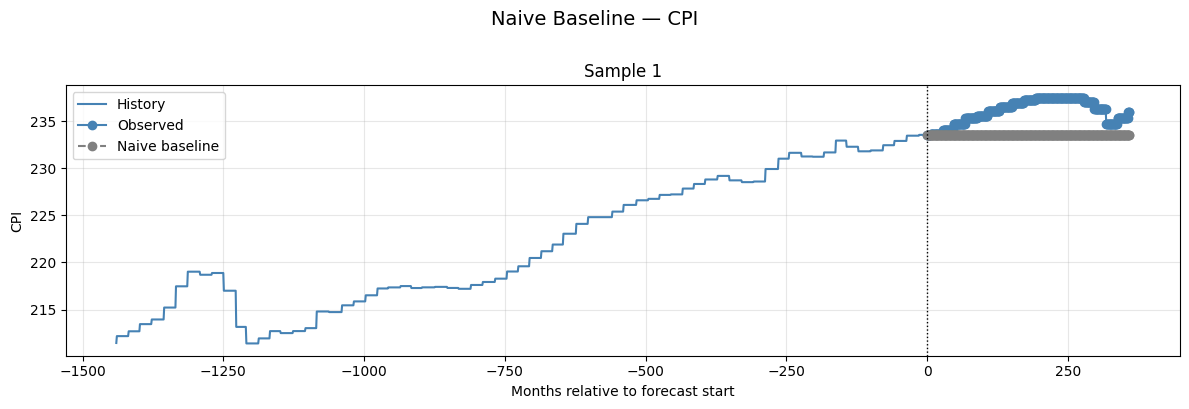

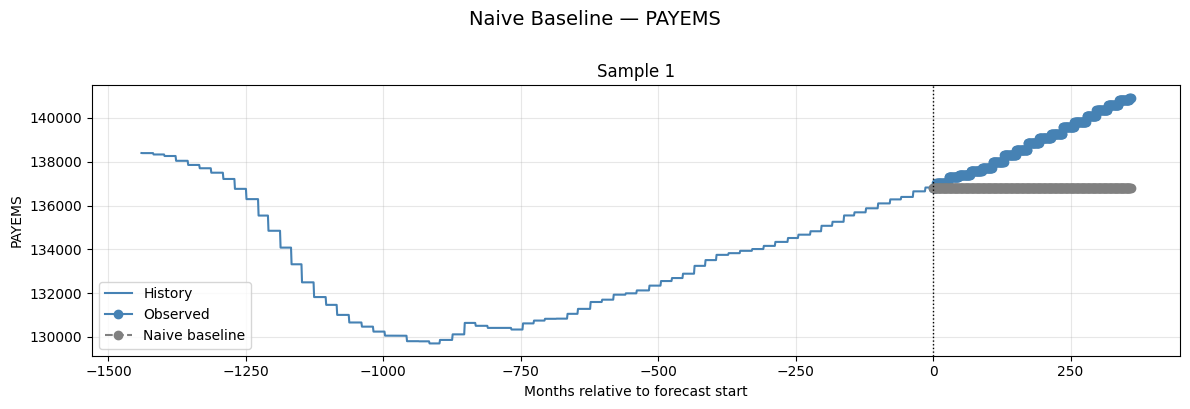

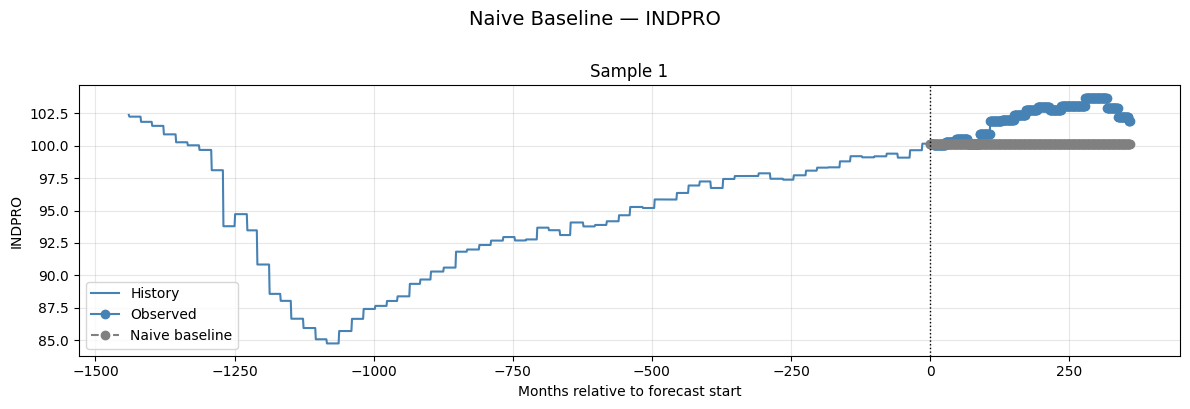

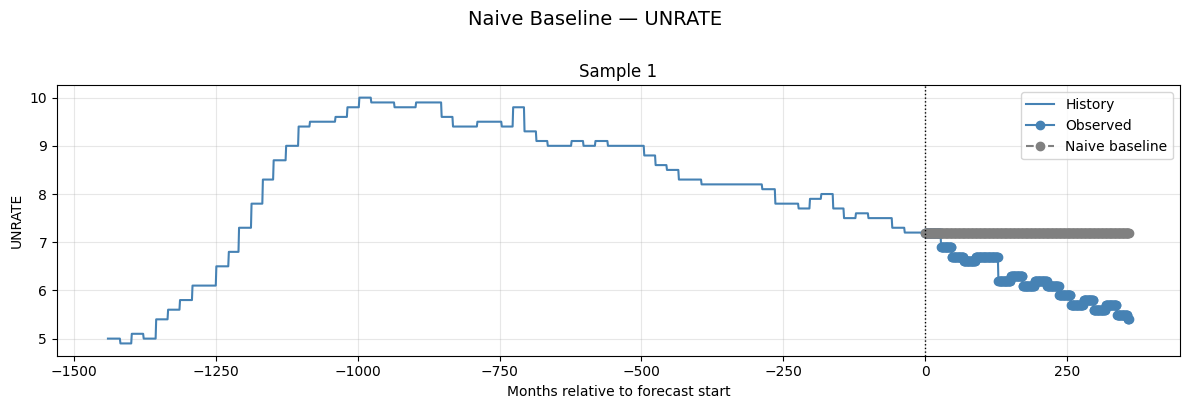

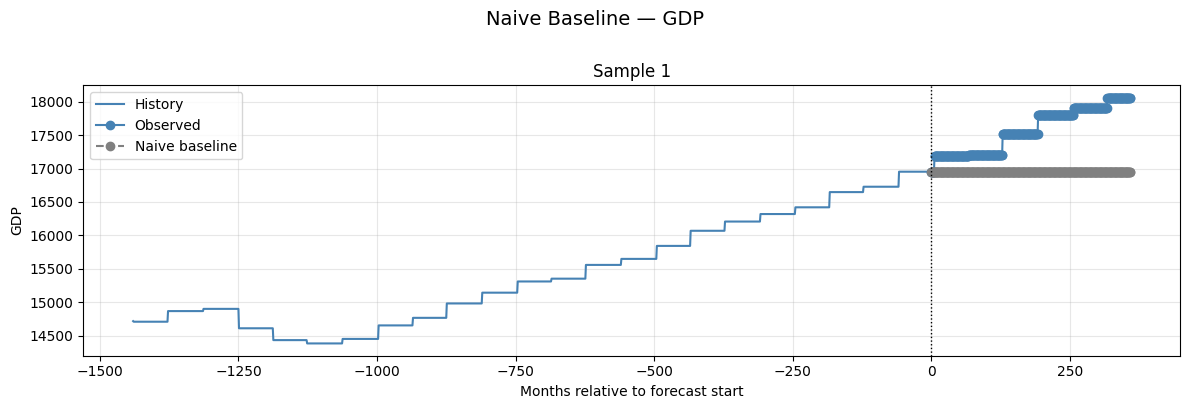

In [26]:
# get encoder history from multi-series validation data
raw_out = best_ms_tft.predict(val_dl_ms, mode='raw', return_x=True)
raw_x   = raw_out.x

n_plots = 4
for target in lag_vars:
    # not just all macro - to leverage tft architecture
    sample_idxs = [i for i, s in enumerate(ms_idx['series_id']) if s == target][:n_plots]

    n = len(sample_idxs)
    fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n))
    if n == 1:
        axes = [axes]

    for plot_i, si in enumerate(sample_idxs):
        ax = axes[plot_i]
        history = raw_x['encoder_target'][si].numpy()
        obs     = ms_acts[si].numpy()
        pred    = ms_baseline[si].numpy()

        n_hist = len(history)
        ax.plot(range(-n_hist, 0), history, color='steelblue', label='History')
        ax.plot(range(len(obs)), obs, marker='o', color='steelblue', label='Observed')
        ax.plot(range(len(pred)), pred, marker='o', linestyle='--', color='gray', label='Naive baseline')
        ax.axvline(0, color='black', linestyle=':', linewidth=1)
        ax.set_title(f'Sample {plot_i + 1}')
        ax.set_xlabel('Months relative to forecast start')
        ax.set_ylabel(target)
        ax.legend()
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'Naive Baseline — {target}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


=== TFT Predictions for: CPI ===


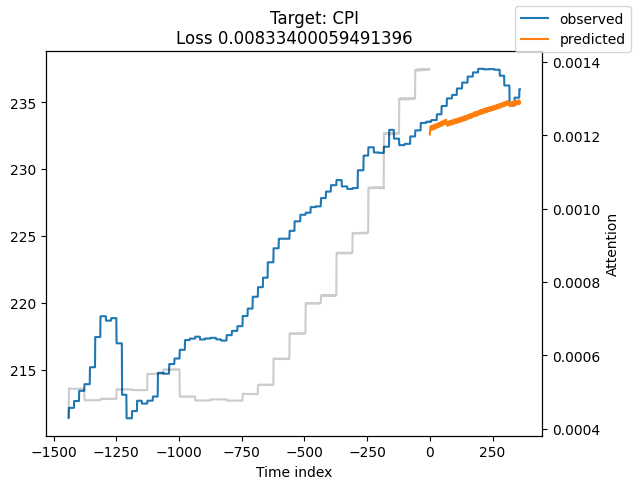

=== TFT Predictions for: PAYEMS ===


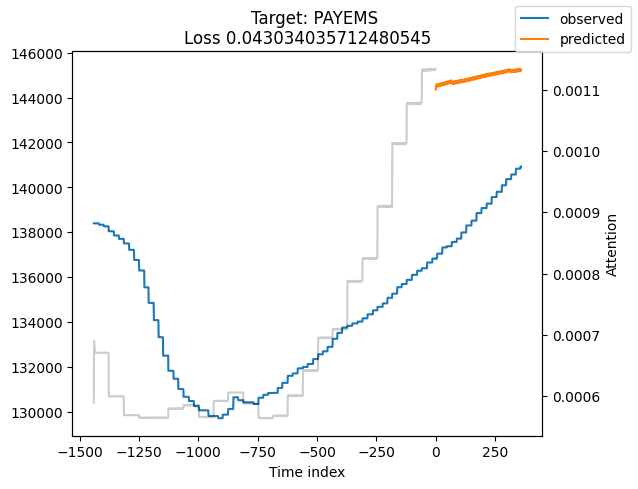

=== TFT Predictions for: INDPRO ===


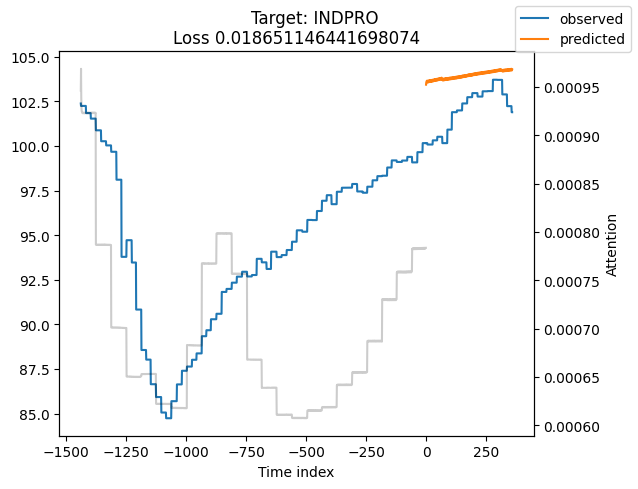

=== TFT Predictions for: UNRATE ===


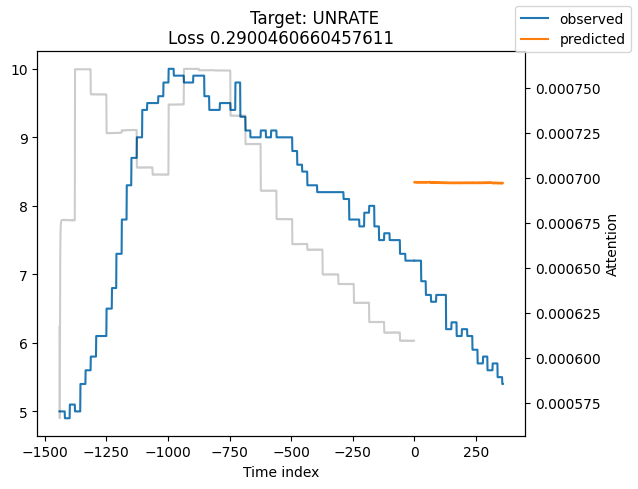

=== TFT Predictions for: GDP ===


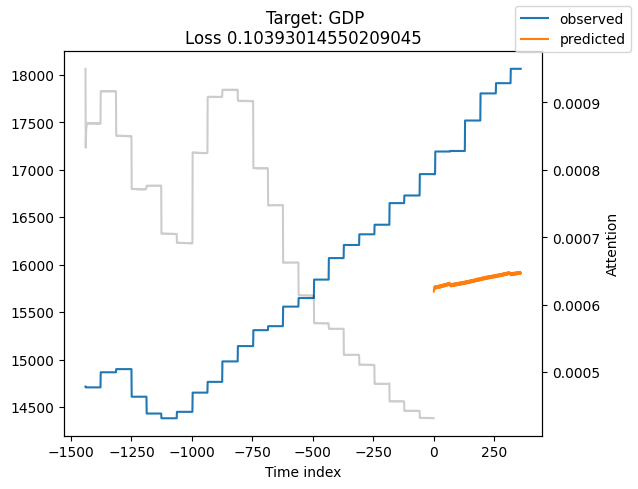

In [23]:
raw_preds_out = best_ms_tft.predict(val_dl_ms, mode='raw', return_x=True)
raw_x_tft     = raw_preds_out.x
raw_preds_tft = raw_preds_out.output

n_plots = 4
for target in lag_vars:
    print(f'=== TFT Predictions for: {target} ===')
    sample_idxs = [i for i, s in enumerate(ms_idx['series_id']) if s == target][:n_plots]
    for si in sample_idxs:
        best_ms_tft.plot_prediction(raw_x_tft, raw_preds_tft, idx=si, add_loss_to_title=True)
        plt.suptitle(f'Target: {target}', y=1.01)
        plt.show()


**Interpretation**: These plots dont look super intuitive, because the method `plot_predictions` labels show attention, but on the left side you see the actual value, in our case, CPI, PAYEMS, INDPRO, UNRATE. 

To compare the results for the Naive Baseline and the TFT, i will plot the results:

In [24]:
losses = pd.DataFrame({
    "Naive": [round(naive_loss[target], ndigits=4) for target in lag_vars],
    "TFT": [round(tft_loss[target], ndigits=4) for target in lag_vars],
}, index=lag_vars)
print(losses)

         Naive     TFT
CPI     0.0106  0.0083
PAYEMS  0.0144  0.0430
INDPRO  0.0187  0.0187
UNRATE  0.1454  0.2900
GDP     0.0361  0.1039


**Before adding Metadata**: the naive is better for all except for CPI for now, let's see how this changes with more metadata

**After adding Metadata (of target var)**: Now the tft is better for both indpro, but a bit worse for cpi.

**After adding Metadata for all vars**: Now the tft is better for cpi, but a lot worse for the others??

**After normalising, pivoting data and combining into one trainer**: tft is only better for cpi, (but tft performs better for indpro, and for payems than before, worse for unrate)

**Addded GDP, quarterly**: now cannot compare numbers to before really, but TFT better than Naive in CPI, UNRATE here